In [1]:
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import viz
import model as dl
import train
import predict

%matplotlib inline

/home/iammrwascal/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reload(data)
reload(viz)
reload(dl)
reload(train)
reload(predict)

<module 'predict' from '/home/iammrwascal/Desktop/programming/digit-classifier/predict.py'>

In [3]:
X, y, test_X = data.load_data()
X.shape, y.shape, test_X.shape

(torch.Size([42000, 1, 28, 28]),
 torch.Size([42000]),
 torch.Size([28000, 1, 28, 28]))

In [4]:
y[:5]

tensor([1, 0, 1, 4, 0], device='cuda:0')

In [5]:
X[1, :, :5, :5]

tensor([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]], device='cuda:0')

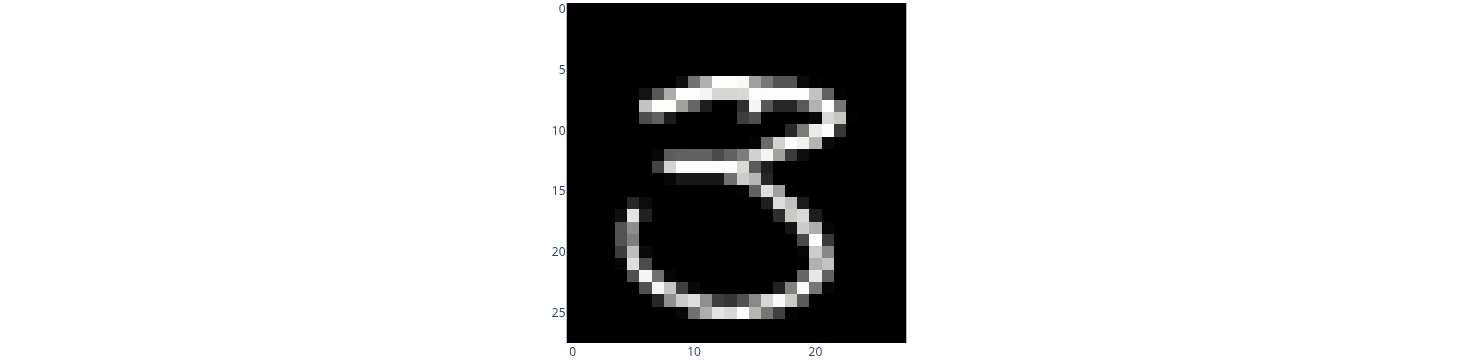

In [6]:
viz.display_img(X[7])

In [7]:
train_X, train_y, val_X, val_y = data.split(X, y)
train_X.shape, train_y.shape, val_X.shape, val_y.shape

(torch.Size([33600, 1, 28, 28]),
 torch.Size([33600]),
 torch.Size([8400, 1, 28, 28]),
 torch.Size([8400]))

In [8]:
train_X, train_y = data.augment(train_X, train_y, 10)
train_X.shape, train_y.shape

(torch.Size([369600, 1, 28, 28]), torch.Size([369600]))

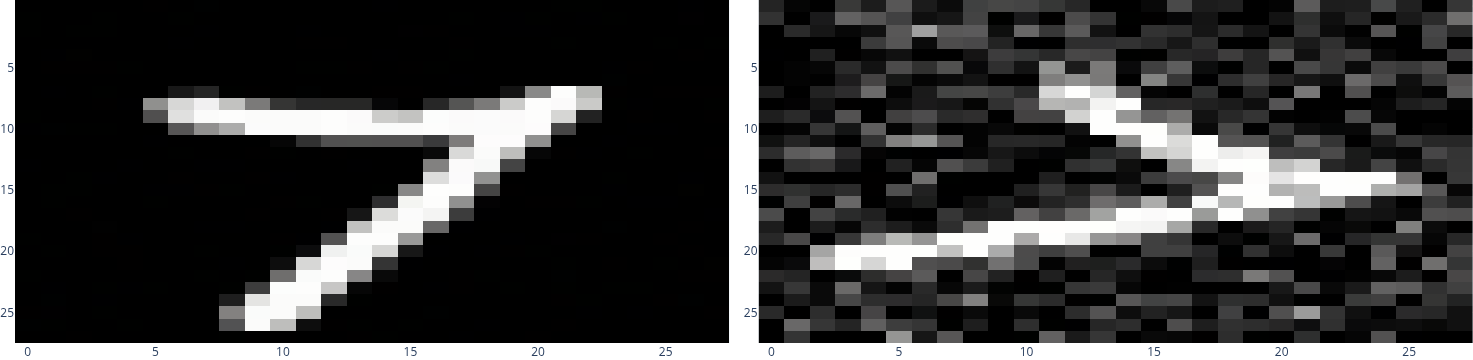

tensor(7, device='cuda:0')


In [9]:
idx = 11
viz.display_imgs(train_X[idx], train_X[33600 + idx])
print(train_y[idx])

In [10]:
train_loader, val_loader = data.create_loader(train_X, train_y, val_X, val_y)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x75f3e0c1d400>,
 <torch.utils.data.dataloader.DataLoader at 0x75f3e0b5e350>)

In [11]:
import torch
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn_model = dl.CNN().to(device)
optimizer = optim.AdamW(cnn_model.parameters(), lr=0.001, weight_decay=1e-5)

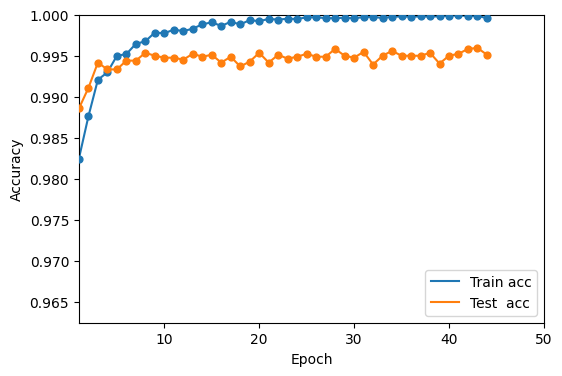

Epochs:   0%|                                                                                                                                                           | 0/50 [01:02<?, ?it/s, loss=0.2028, test_acc=0.989, train_acc=0.982]

model dumped with test accuracy 0.9885714285714285


Epochs:   2%|██▉                                                                                                                                                | 1/50 [02:53<50:46, 62.18s/it, loss=0.0701, test_acc=0.991, train_acc=0.988]

model dumped with test accuracy 0.9910714285714286


Epochs:   4%|█████▊                                                                                                                                           | 2/50 [05:59<1:12:48, 91.01s/it, loss=0.0530, test_acc=0.994, train_acc=0.992]

...

Epochs:  54%|█████████████████████████████████████████████████████████████████████████████▏                                                                 | 27/50 [1:19:48<39:07, 102.06s/it, loss=0.0092, test_acc=0.996, train_acc=1.000]

model dumped with test accuracy 0.9958333333333333


Epochs:  84%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                       | 42/50 [1:46:19<15:36, 117.01s/it, loss=0.0075, test_acc=0.996, train_acc=1.000]

model dumped with test accuracy 0.9959523809523809


Epochs:  88%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                 | 44/50 [1:47:45<10:51, 108.60s/it, loss=0.0072, test_acc=0.995, train_acc=1.000]

In [ ]:
num_epochs = 50
train.run(num_epochs, cnn_model, optimizer, train_loader, val_loader)

In [11]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = dl.load('results/model.safetensors').to(device)
cnn_model

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (flatten): Flatten(start

In [43]:
dl.dump(model, 'results/model.safetensors')

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions_all, labels_all = predict.evaluate_test(cnn_model, val_loader)
predictions_df = pd.DataFrame({'pred': predictions_all, 'labels': labels_all})
ConfusionMatrixDisplay.from_predictions(labels_all, predictions_all, labels=range(10))

In [ ]:
error_ind = predictions_df[predictions_df['pred'] != predictions_df['labels']].index
viz.plot_images(val_X[error_ind, :, :, :], labels_all[error_ind], predictions_all[error_ind])

In [ ]:
train_embedding_index = data.store_train_embeddings(train_loader, cnn_model)
train_X_matched, train_y_matched = data.search_train_embeddings(val_X[error_ind, :, :, :], cnn_model, k=5)
train_X_matched.shape, train_y_matched.shape

In [ ]:
viz.plot_image_matches(val_X[error_ind, :, :, :], labels_all[error_ind], predictions_all[error_ind], train_X_matched, train_y_matched)

In [14]:
test_loader = data.create_loader_test(test_X)
predict.generate_submission_csv(model, test_loader)

Saved submission to results/submit-020526.csv
